In [175]:
import kagglehub
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Baixar o dataset
path_heart = kagglehub.dataset_download("oktayrdeki/heart-disease")

print("Path to dataset files:", path_heart)

# Mostrar os arquivos presentes na pasta
print(os.listdir(path_heart))


Path to dataset files: C:\Users\italo\.cache\kagglehub\datasets\oktayrdeki\heart-disease\versions\1
['heart_disease.csv']


In [176]:
#Fazendo a leitura dos arquivos
heart = pd.read_csv(os.path.join(path_heart, "heart_disease.csv"))

print(heart.head())

    Age  Gender  Blood Pressure  Cholesterol Level Exercise Habits Smoking  \
0  56.0    Male           153.0              155.0            High     Yes   
1  69.0  Female           146.0              286.0            High      No   
2  46.0    Male           126.0              216.0             Low      No   
3  32.0  Female           122.0              293.0            High     Yes   
4  60.0    Male           166.0              242.0             Low     Yes   

  Family Heart Disease Diabetes        BMI High Blood Pressure  ...  \
0                  Yes       No  24.991591                 Yes  ...   
1                  Yes      Yes  25.221799                  No  ...   
2                   No       No  29.855447                  No  ...   
3                  Yes       No  24.130477                 Yes  ...   
4                  Yes      Yes  20.486289                 Yes  ...   

  High LDL Cholesterol Alcohol Consumption Stress Level Sleep Hours  \
0                   No           

In [177]:
#analise geral
print("Dimensões do dataset:")
print(heart.shape)

print("\nTipos das colunas:")
print(heart.dtypes)

print("\nValores ausentes:")
print(heart.isnull().sum())

print("\nDistribuição da variável alvo:")
print(heart["Heart Disease Status"].value_counts())

Dimensões do dataset:
(10000, 21)

Tipos das colunas:
Age                     float64
Gender                      str
Blood Pressure          float64
Cholesterol Level       float64
Exercise Habits             str
Smoking                     str
Family Heart Disease        str
Diabetes                    str
BMI                     float64
High Blood Pressure         str
Low HDL Cholesterol         str
High LDL Cholesterol        str
Alcohol Consumption         str
Stress Level                str
Sleep Hours             float64
Sugar Consumption           str
Triglyceride Level      float64
Fasting Blood Sugar     float64
CRP Level               float64
Homocysteine Level      float64
Heart Disease Status        str
dtype: object

Valores ausentes:
Age                       29
Gender                    19
Blood Pressure            19
Cholesterol Level         30
Exercise Habits           25
Smoking                   25
Family Heart Disease      21
Diabetes                  30
BMI      

In [178]:
sem_doenca= heart[heart["Heart Disease Status"]=="No"]
com_doenca= heart[heart["Heart Disease Status"]=="Yes"]

sem_doenca_r=sem_doenca.sample(n=2000, random_state=42)
com_doenca_r=com_doenca.sample(n=2000, random_state=42)

heart_r=pd.concat([sem_doenca_r,com_doenca_r])

heart_r=heart_r.sample(frac=1, random_state=42).reset_index(drop=True)


print(heart_r["Heart Disease Status"].value_counts())

Heart Disease Status
No     2000
Yes    2000
Name: count, dtype: int64


In [179]:
#tratamento de dados
X = heart_r.drop(columns=["Heart Disease Status"])
y = heart_r["Heart Disease Status"].map({"No": 0,"Yes": 1})

variaveis_numericas = [
    "Age",
    "Blood Pressure",
    "Cholesterol Level",
    "BMI",
    "Sleep Hours",
    "Triglyceride Level",
    "Fasting Blood Sugar",
    "CRP Level",
    "Homocysteine Level"]
variaveis_categoricas = [
    "Gender",
    "Exercise Habits",
    "Smoking",
    "Family Heart Disease",
    "Diabetes",
    "High Blood Pressure",
    "Low HDL Cholesterol",
    "High LDL Cholesterol",
    "Stress Level",
    "Sugar Consumption"]

variavel_alcool = ["Alcohol Consumption"]

In [180]:
from sklearn.model_selection import train_test_split

X_treino, X_teste, y_treino, y_teste = train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)

print("Dados de treinamento:", X_treino.shape)
print("Dados de teste:", X_teste.shape)

print(y.value_counts())
print("Valores ausentes no alvo:", y.isnull().sum())

Dados de treinamento: (3200, 20)
Dados de teste: (800, 20)
Heart Disease Status
0    2000
1    2000
Name: count, dtype: int64
Valores ausentes no alvo: 0


In [181]:
#Bibliotecas
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

In [182]:
tratamento_numerico = Pipeline([( "preencher_mediana",SimpleImputer(strategy="median"))])

tratamento_categorico = Pipeline([("preencher_frequente",SimpleImputer(strategy="most_frequent")),
    ("codificacao",OneHotEncoder(handle_unknown="ignore"))])

tratamento_alcool = Pipeline([("preencher_desconhecido",SimpleImputer(strategy="constant",fill_value="Unknown")),
    ("codificacao",OneHotEncoder(handle_unknown="ignore"))])

In [183]:
pre_processamento = ColumnTransformer([
    ("numericas",tratamento_numerico,variaveis_numericas),
    ("categoricas",tratamento_categorico,variaveis_categoricas),
    ("alcool",tratamento_alcool,variavel_alcool)])

In [184]:
from sklearn.ensemble import RandomForestClassifier
modelo_random_forest=Pipeline([("pre_processamento",pre_processamento),("modelo",
    RandomForestClassifier(n_estimators=500,
                           max_depth=None,
                           min_samples_split=2,
                           min_samples_leaf=1,
                           class_weight={0: 1, 1: 3},
                           n_jobs=-1,
                           random_state=42))])


In [185]:
modelo_random_forest.fit(X_treino, y_treino)
print("Modelo treinado com sucesso!")

Modelo treinado com sucesso!


As métricas mais importantes serão:

Recall: quantas pessoas com doença foram identificadas;

Precisão: quantas classificadas com doença realmente pertenciam à classe;

F1-score: equilíbrio entre precisão e recall;

AUC: capacidade de separar as duas classes;

Matriz de confusão: quantidade de erros em cada classe.

In [186]:
previsoes_rf = modelo_random_forest.predict(X_teste)

probabilidades_rf = modelo_random_forest.predict_proba(X_teste)[:, 1]

In [187]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,)

In [188]:
acuracia_rf= accuracy_score(y_teste, previsoes_rf)
precisao_rf=precision_score(y_teste, previsoes_rf, zero_division=0)
recall_rf=recall_score(y_teste, previsoes_rf, zero_division=0)
f1_rf=f1_score(y_teste, previsoes_rf, zero_division=0)
auc_rf=roc_auc_score(y_teste, previsoes_rf)

In [189]:
print("RESULTADOS DA RANDOM FOREST")
print(f"Acurácia: {acuracia_rf:.3f}")
print(f"Precisão: {precisao_rf:.3f}")
print(f"Recall: {recall_rf:.3f}")
print(f"F1-score: {f1_rf:.3f}")
print(f"AUC: {auc_rf:.3f}")

RESULTADOS DA RANDOM FOREST
Acurácia: 0.517
Precisão: 0.528
Recall: 0.333
F1-score: 0.408
AUC: 0.517


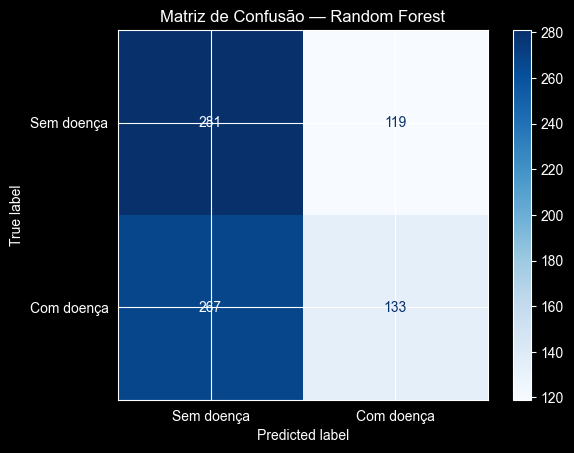

In [190]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_teste,
    previsoes_rf,
    display_labels=["Sem doença","Com doença"],cmap="Blues")

plt.title("Matriz de Confusão — Random Forest")
plt.show()